# EDA - BIHAR-TAXI

Notebook d'analyse exploratoire dans l'esprit du projet BIHAR-DIABETES, adapté au dataset NYC Taxi Trip Duration.

In [21]:
import os
import sqlite3

import numpy as np
import pandas as pd
try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    %pip install matplotlib
    import matplotlib.pyplot as plt
try:
    import seaborn as sns
except ModuleNotFoundError:
    %pip install seaborn
    import seaborn as sns

import sys
sys.path.insert(0, os.path.abspath('..'))
import common

sns.set_style('darkgrid')
pd.set_option('display.max_columns', 100)

In [22]:
DB_PATH = common.CONFIG['paths']['db_path']
DB_PATH

'/Users/auzoufrederic/MLOPS/BIHAR-TAXI/data/taxi.db'

In [23]:
with sqlite3.connect(DB_PATH) as con:
    train = pd.read_sql('SELECT * FROM train', con, parse_dates=['pickup_datetime'])
    test = pd.read_sql('SELECT * FROM test', con, parse_dates=['pickup_datetime'])

print('Train shape:', train.shape)
print('Test shape :', test.shape)

Train shape: (1021050, 9)
Test shape : (437594, 9)


In [24]:
train.head()

,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,2,2016-05-03 09:03:08,2,-73.979813,40.752529,-73.982681,40.763680,N,844
1,1,2016-01-01 16:40:51,1,-73.977623,40.746296,-73.968414,40.788933,N,1001
2,1,2016-04-24 13:57:03,1,-73.950699,40.779404,-73.863129,40.768608,N,1048
3,2,2016-01-10 17:03:47,1,-73.984558,40.721802,-73.976753,40.752213,N,784
4,1,2016-02-25 17:37:36,1,-73.967720,40.768742,-73.977173,40.789875,N,732


In [25]:
train.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
vendor_id,1021050.0,NaN,NaN,NaN,1.535298,1.0,1.0,2.0,2.0,2.0,0.498753
pickup_datetime,1021050,NaN,NaN,NaN,2016-04-01 09:53:22.825644288,2016-01-01 00:00:17,2016-02-17 16:33:59.249999872,2016-04-01 16:06:20,2016-05-15 03:15:51.500000,2016-06-30 23:59:39,NaN
passenger_count,1021050.0,NaN,NaN,NaN,1.663364,0.0,1.0,1.0,2.0,9.0,1.312695
pickup_longitude,1021050.0,NaN,NaN,NaN,-73.973468,-121.933235,-73.991875,-73.98175,-73.967339,-61.335529,0.06454
pickup_latitude,1021050.0,NaN,NaN,NaN,40.750926,34.359695,40.737335,40.754105,40.768341,51.881084,0.033474
dropoff_longitude,1021050.0,NaN,NaN,NaN,-73.973393,-121.933205,-73.991318,-73.979752,-73.963028,-61.335529,0.064161
dropoff_latitude,1021050.0,NaN,NaN,NaN,40.751804,32.181141,40.735867,40.754528,40.769806,43.921028,0.035816
store_and_fwd_flag,1021050,2,N,1015403,NaN,NaN,NaN,NaN,NaN,NaN,NaN
trip_duration,1021050.0,NaN,NaN,NaN,961.719308,1.0,397.0,663.0,1075.0,3526282.0,5900.133069


In [26]:
missing = train.isna().sum().sort_values(ascending=False)
missing[missing > 0]

Series([], dtype: int64)

## Analyse de la cible

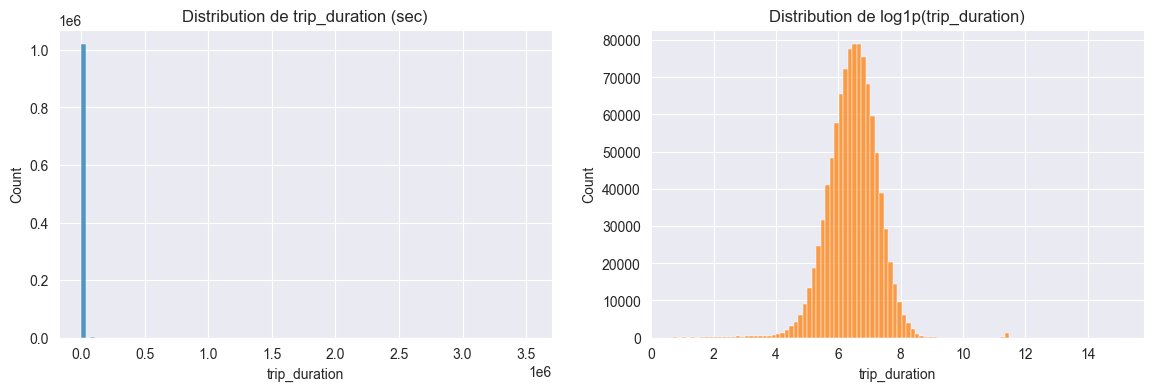

In [27]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(train['trip_duration'], bins=100, ax=ax[0])
ax[0].set_title('Distribution de trip_duration (sec)')

sns.histplot(np.log1p(train['trip_duration']), bins=100, ax=ax[1], color='tab:orange')
ax[1].set_title('Distribution de log1p(trip_duration)')
plt.show()

## Features temporelles

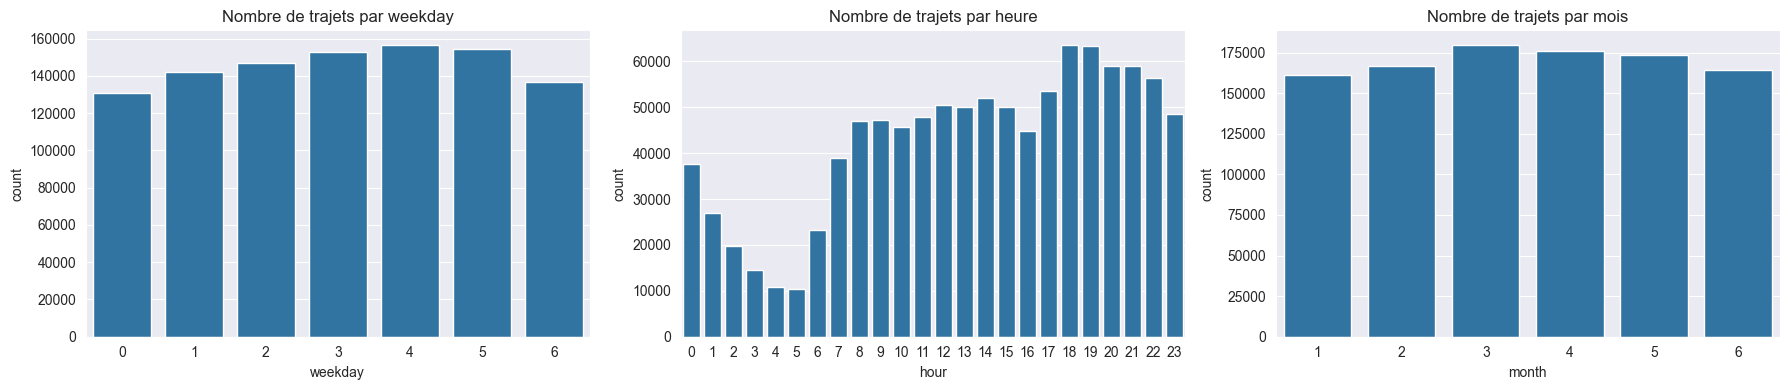

In [28]:
tmp = train.copy()
tmp['weekday'] = tmp['pickup_datetime'].dt.weekday
tmp['hour'] = tmp['pickup_datetime'].dt.hour
tmp['month'] = tmp['pickup_datetime'].dt.month

fig, ax = plt.subplots(1, 3, figsize=(18, 4))
sns.countplot(x='weekday', data=tmp, ax=ax[0])
ax[0].set_title('Nombre de trajets par weekday')
sns.countplot(x='hour', data=tmp, ax=ax[1])
ax[1].set_title('Nombre de trajets par heure')
sns.countplot(x='month', data=tmp, ax=ax[2])
ax[2].set_title('Nombre de trajets par mois')
plt.tight_layout()
plt.show()

## Corrélations numériques

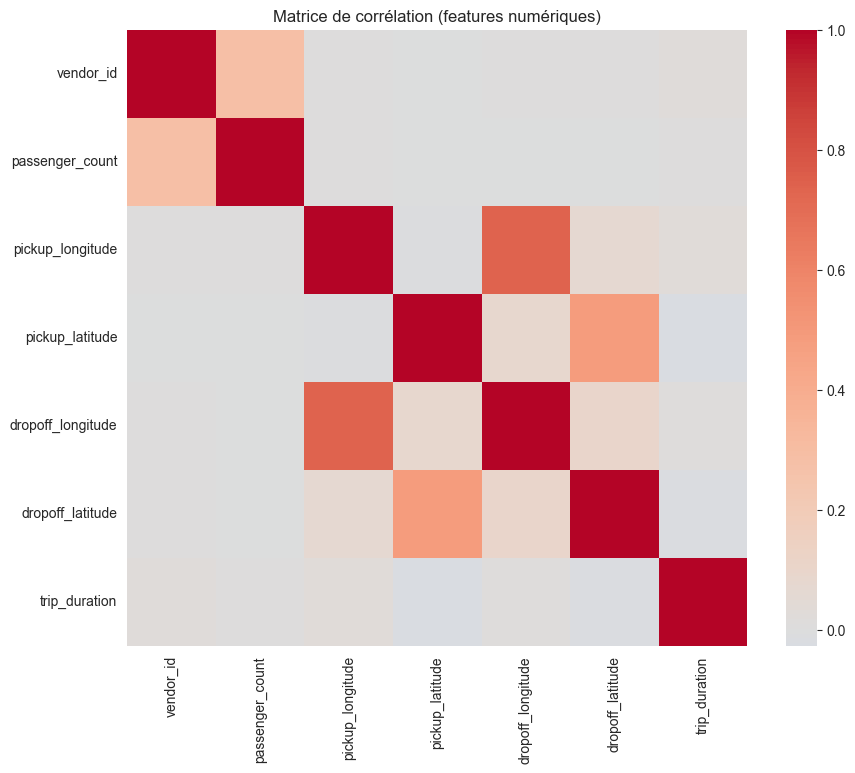

In [29]:
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
corr = train[num_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Matrice de corrélation (features numériques)')
plt.show()

## Task 1. Import data (rappel)

Les données sont déjà chargées dans `train` et `test` depuis SQLite.

Objectifs:
- vérifier dimensions et types
- retirer colonnes non exploitables
- préparer des variables `X_train`, `X_test`, `y_train`, `y_test`.

In [30]:
print('Train:', train.shape)
print('Test :', test.shape)
print('\nDtypes train:')
display(train.dtypes)

X_train = train.drop(columns=['trip_duration']).copy()
y_train = train['trip_duration'].copy()
X_test = test.drop(columns=['trip_duration']).copy()
y_test = test['trip_duration'].copy()

display(X_train.head(3))
display(y_train.head(3))

Train: (1021050, 9)
Test : (437594, 9)

Dtypes train:


vendor_id                      int64
pickup_datetime       datetime64[ns]
passenger_count                int64
pickup_longitude             float64
pickup_latitude              float64
dropoff_longitude            float64
dropoff_latitude             float64
store_and_fwd_flag            object
trip_duration                  int64
dtype: object

,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag
0,2,2016-05-03 09:03:08,2,-73.979813,40.752529,-73.982681,40.763680,N
1,1,2016-01-01 16:40:51,1,-73.977623,40.746296,-73.968414,40.788933,N
2,1,2016-04-24 13:57:03,1,-73.950699,40.779404,-73.863129,40.768608,N


0     844
1    1001
2    1048
Name: trip_duration, dtype: int64

## Task 2. Target variable

- Observer la distribution de `trip_duration`
- Utiliser la transformation `log1p`
- Définir la métrique RMSLE

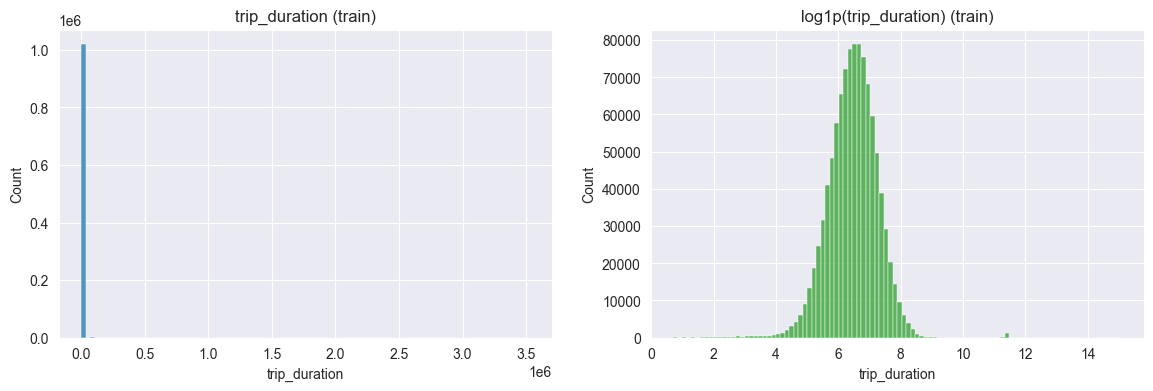

In [31]:
from sklearn.metrics import root_mean_squared_error

def rmsle(y_true, y_pred):
    y_pred = np.maximum(y_pred, 0)
    return root_mean_squared_error(np.log1p(y_true), np.log1p(y_pred))

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(y_train, bins=100, ax=ax[0])
ax[0].set_title('trip_duration (train)')
sns.histplot(y_train_log, bins=100, ax=ax[1], color='tab:green')
ax[1].set_title('log1p(trip_duration) (train)')
plt.show()

## Task 3. Baseline

Calcul de la meilleure constante sur la cible transformée.

In [32]:
y_baseline_log = y_train_log.mean()
y_baseline = np.expm1(y_baseline_log)

print(f'Baseline prediction (log): {y_baseline_log:.4f}')
print(f'Baseline prediction (sec): {y_baseline:.0f}')
print(f'RMSLE train: {rmsle(y_train, np.full(len(y_train), y_baseline)):.4f}')
print(f'RMSLE test : {rmsle(y_test, np.full(len(y_test), y_baseline)):.4f}')

Baseline prediction (log): 6.4671
Baseline prediction (sec): 643
RMSLE train: 0.7961
RMSLE test : 0.7950


## Task 4-6. Feature engineering + Ridge

On applique des features inspirées du Colab (`model.features.build_model_features`) puis on entraîne un modèle Ridge avec preprocessing.

In [33]:
from model.features import build_model_features
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

X_train_fe = build_model_features(X_train)
X_test_fe = build_model_features(X_test)

num_features = [
    'log_distance_haversine', 'hour', 'abnormal_period',
    'is_high_traffic_trip', 'is_high_speed_trip',
    'is_rare_pickup_point', 'is_rare_dropoff_point',
    'vendor_id', 'store_and_fwd_flag', 'passenger_count'
]
cat_features = ['weekday', 'month']

preprocess = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown='ignore'), cat_features),
    ('scale', StandardScaler(), num_features)
])

ridge = Pipeline([
    ('prep', preprocess),
    ('model', Ridge())
])

ridge.fit(X_train_fe[num_features + cat_features], y_train_log)
pred_train_log = ridge.predict(X_train_fe[num_features + cat_features])
pred_test_log = ridge.predict(X_test_fe[num_features + cat_features])

print(f'Ridge RMSE log train: {root_mean_squared_error(y_train_log, pred_train_log):.4f}')
print(f'Ridge RMSE log test : {root_mean_squared_error(y_test_log, pred_test_log):.4f}')
print(f'Ridge R2 log test   : {r2_score(y_test_log, pred_test_log):.4f}')

Ridge RMSE log train: 0.4932
Ridge RMSE log test : 0.4922
Ridge R2 log test   : 0.6167


## Task 7. Nettoyage léger + Ridge vs Lasso

- suppression des outliers simples sur `trip_duration`
- comparaison Ridge / Lasso

In [34]:
from sklearn.linear_model import Lasso

q_low, q_high = y_train.quantile(0.01), y_train.quantile(0.99)
mask = (y_train >= q_low) & (y_train <= q_high)

X_train_clean = X_train[mask]
y_train_clean = y_train[mask]
y_train_clean_log = np.log1p(y_train_clean)

X_train_clean_fe = build_model_features(X_train_clean)

lasso = Pipeline([
    ('prep', preprocess),
    ('model', Lasso(alpha=0.01, max_iter=20000))
])

ridge.fit(X_train_clean_fe[num_features + cat_features], y_train_clean_log)
lasso.fit(X_train_clean_fe[num_features + cat_features], y_train_clean_log)

ridge_test_log = ridge.predict(X_test_fe[num_features + cat_features])
lasso_test_log = lasso.predict(X_test_fe[num_features + cat_features])

print(f'Ridge test RMSE log: {root_mean_squared_error(y_test_log, ridge_test_log):.4f}')
print(f'Lasso test RMSE log: {root_mean_squared_error(y_test_log, lasso_test_log):.4f}')

Ridge test RMSE log: 0.4948
Lasso test RMSE log: 0.5012


## Task 8. Using other algorithms

Test rapide de modèles arbres/ensembles sur les mêmes features.

In [35]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Encodage one-hot direct pour modèles arbres
X_train_model = pd.get_dummies(X_train_fe[num_features + cat_features], columns=cat_features, drop_first=False)
X_test_model = pd.get_dummies(X_test_fe[num_features + cat_features], columns=cat_features, drop_first=False)
X_test_model = X_test_model.reindex(columns=X_train_model.columns, fill_value=0)

models = {
    'DecisionTree': DecisionTreeRegressor(max_depth=12, random_state=42),
    'RandomForest': RandomForestRegressor(n_estimators=200, max_depth=16, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train_model, y_train_log)
    pred = model.predict(X_test_model)
    score = root_mean_squared_error(y_test_log, pred)
    results.append({'model': name, 'rmse_log_test': score})

results_df = pd.DataFrame(results).sort_values('rmse_log_test')
results_df

,model,rmse_log_test
1,RandomForest,0.462805
2,GradientBoosting,0.463833
0,DecisionTree,0.469236


In [36]:
summary = pd.DataFrame([
    {'model': 'Baseline constant', 'rmse_log_test': rmsle(y_test, np.full(len(y_test), y_baseline))},
    {'model': 'Ridge', 'rmse_log_test': root_mean_squared_error(y_test_log, ridge_test_log)},
    {'model': 'Lasso', 'rmse_log_test': root_mean_squared_error(y_test_log, lasso_test_log)}
])

if 'results_df' in globals():
    summary = pd.concat([summary, results_df], ignore_index=True)

summary.sort_values('rmse_log_test')

,model,rmse_log_test
3,RandomForest,0.462805
4,GradientBoosting,0.463833
5,DecisionTree,0.469236
1,Ridge,0.494780
2,Lasso,0.501159
0,Baseline constant,0.795027
